In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import (
    browse_swot_250,
    add_mask_inside_swot,
    build_swath_polygon,
    swot_interp_grad_one,
)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from rasterio.transform import Affine

import pynsitu as pyn

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


____
# Colocalization definition
- select the nearest in time of a SWOT image drifter point 
- import SWOT data at this point :
    - for SWOT-250m interpolate on a cartesian grid, compute gradient on this grid, interpolate at the drifter position
    - for SWOT-2km compute gradient, interpolate at the drifter position
    - for SWOT-nadir, select nearest nadir point, comute gradient at this point

_______
# Vizualize

In [2]:
dfs = browse_swot_250().reset_index()
dfs

,day,pass_number,cycle_number,file,time,start_time_cut,end_time_cut
0,2023-04-01,3,478,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-01 23:42:32.696536000,2023-04-01 11:47:13.760762624,2023-04-02 11:37:51.561104544
1,2023-04-02,3,479,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-02 23:33:10.425673088,2023-04-02 11:37:51.561104544,2023-04-03 11:28:29.307429408
2,2023-04-03,3,480,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-03 23:23:48.189185728,2023-04-03 11:28:29.307429408,2023-04-04 11:19:07.046608544
3,2023-04-04,3,481,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-04 23:14:25.904031360,2023-04-04 11:19:07.046608544,2023-04-05 11:09:44.780262144
4,2023-04-05,3,482,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-05 23:05:03.656492928,2023-04-05 11:09:44.780262144,2023-04-06 11:00:22.763027360
...,...,...,...,...,...,...,...
182,2023-07-05,16,573,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-07-05 19:33:50.331633280,2023-07-05 07:38:31.368841152,2023-07-06 07:29:09.302501440
183,2023-07-06,16,574,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-07-06 19:24:28.273369600,2023-07-06 07:29:09.302501440,2023-07-07 07:19:47.209324384
184,2023-07-07,16,575,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-07-07 19:15:06.145279168,2023-07-07 07:19:47.209324384,2023-07-08 07:10:25.074586176
185,2023-07-08,16,576,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-07-08 19:05:44.003893184,2023-07-08 07:10:25.074586176,2023-07-09 07:01:02.936174400


In [21]:
drifters_sources = "all_med_variational_10min_v0.nc"
df = pd.read_csv(
    os.path.join(zarr_dir, "drifters_" + drifters_sources.replace(".nc", ".csv"))
)

_______
# Colocalize with SWOT

In [22]:
ggrad_variables = [
    "cvl_mean_dynamic_topography_cnes_cls_22",
    "cvl_mean_sea_surface_cnes_22_hybrid",
    "cvl_ocean_tide_fes_2022",
    "cvl_ssha_reference",
    "duacs_ssha_karin_2_calibrated",
    "duacs_ssha_karin_2_filtered",
]

variables = [
    "duacs_relative_vorticity",
    "duacs_speed_meridional",
    "duacs_speed_meridional_abs",
    "duacs_speed_zonal",
    "duacs_speed_zonal_abs",
    "cvl_swh_model",
]

In [23]:
def swot_interp_grad_one(
    swath, cycle, lond, latd, row_number, variables, ggrad_variables
):
    g = 9.81
    from scipy.interpolate import interp2d
    from scipy.interpolate import LinearNDInterpolator

    total_variables = variables + ggrad_variables
    # SWOT
    dss = xr.open_dataset(
        dfs.where((dfs.pass_number == swath) & (dfs.cycle_number == cycle))
        .dropna()
        .file.values[0]
    )[
        [
            "longitude",
            "latitude",
            "time",
        ]
        + total_variables
    ]

    # Create coordinates for num_lines and num_pixels
    dss["num_lines"] = np.arange(len(dss.num_lines))
    dss["num_pixels"] = np.arange(len(dss.num_pixels))

    # Create the interesting adt + corrections added back
    # dss['eta'] = dss.cvl_mean_dynamic_topography_cnes_cls_22 + dss.cvl_ocean_tide_fes_2022 + dss.duacs_ssha_karin_2_filtered
    # dss.eta.attrs={'long_name':'ADT+ocean tide correction', 'unit':'m'}

    # Projection in local swath ref (y in the num_pixels direction and x in the num_lines
    xd, yd = lonlat2xy(
        dss.attrs["lonc"],
        dss.attrs["latc"],
        dss.attrs["phi"],
        lond,
        latd,
        lon1=None,
        lat1=None,
    )
    x, y = lonlat2xy(
        dss.attrs["lonc"],
        dss.attrs["latc"],
        dss.attrs["phi"],
        dss.longitude,
        dss.latitude,
        lon1=None,
        lat1=None,
    )
    dss["x"] = xr.DataArray(x, dims=["num_lines", "num_pixels"])
    dss["y"] = xr.DataArray(y, dims=["num_lines", "num_pixels"])
    dss = dss.set_coords(["x", "y"])

    # GET A PERFECTLY REGULAR GRID FROM THE PREVIOUS LOCAL SWATH GRID
    # small sub-grid for scipy interp
    try:
        dl = 5 * 1000
        test_x = (dss.x > xd - dl) & (dss.x < xd + dl)
        ds_ = dss.where(test_x, drop=True)
        test_y = (ds_.y > yd - dl) & (ds_.y < yd + dl)
        ds_ = ds_.where(test_y, drop=True)
    except:  # correct if the drifter point is two far outside the swath (must be corrected by a better selection of drifters under the swath)
        return pd.Series(
            np.zeros(len(variables) + 2 * len(ggrad_variables)),
            index=variables
            + ["ggradx_" + var for var in ggrad_variables]
            + ["ggrady_" + var for var in ggrad_variables],
        )

    try:
        # coordinates of the regular grid
        dll = 125
        box_x = np.arange(ds_.x.min() - dll, ds_.x.max() + dll, dll)
        box_y = np.arange(ds_.y.min() - dll, ds_.y.max() + dll, dll)
        # interpolate the interesting variable on this regular grid

        try:
            D = {}
            for var in total_variables:
                Z = ds_[var].values.ravel()
                X = ds_.x.values.ravel()
                Y = ds_.y.values.ravel()
                _ds = xr.Dataset(
                    data_vars=dict(x=(["a"], X), y=(["a"], Y), z=(["a"], Z))
                )
                _ds = _ds.dropna("a")
                # f = LinearNDInterpolator(list(zip(x, y)), z)
                # box_x, box_y = np.meshgrid(box_x, box_y) # for LinearNDInterpolator
                f = interp2d(_ds.x, _ds.y, _ds.z)
                Znew = f(box_x, box_y)
                da = xr.DataArray(
                    Znew, coords={"x": box_x, "y": box_y}, dims=["y", "x"], name=var
                )
                D[var] = da
        except:
            D = {}
            for var in total_variables:
                lx = len(box_x)
                ly = len(box_y)
                da = xr.DataArray(
                    np.zeros((ly, lx)),
                    coords={"x": box_x, "y": box_y},
                    dims=["y", "x"],
                    name=var,
                )
                D[var] = da
            print("pb with interp", cycle, swath, row_number)

    except:
        D = {}
        for var in total_variables:
            box_x = np.arange(43)
            box_y = np.arange(41)
            lx = 43
            ly = 41
            da = xr.DataArray(
                np.zeros((ly, lx)),
                coords={"x": box_x, "y": box_y},
                dims=["y", "x"],
                name=var,
            )
            D[var] = da
        print("pb with ds_.min()", cycle, swath, row_number)

    # Compute g * gradient
    Dx = {"ggradx_" + var: g * D[var].differentiate("x") for var in ggrad_variables}
    Dy = {"ggrady_" + var: g * D[var].differentiate("y") for var in ggrad_variables}

    # Interpolate at the drifter position
    Dxd = {var: float(Dx[var].interp(x=xd, y=yd).values) for var in Dx}
    Dyd = {var: float(Dy[var].interp(x=xd, y=yd).values) for var in Dy}
    D = {var: float(D[var].interp(x=xd, y=yd).values) for var in variables}
    print(row_number)

    return pd.concat([pd.Series(D), pd.Series(Dxd), pd.Series(Dyd)])


def df_swot_interp_grad_one(dfr, variables, ggrad_variables):
    return swot_interp_grad_one(
        dfr.pass_number,
        dfr.cycle_number,
        dfr.longitude,
        dfr.latitude,
        dfr.row_number,
        variables,
        ggrad_variables,
    )


def partition_swot_interp_grad(df):
    return df.apply(
        df_swot_interp_grad_one,
        variables=variables,
        ggrad_variables=ggrad_variables,
        axis=1,
        result_type="expand",
    )

In [6]:
# FOR TEST
df_ = df.iloc[0:100]
from dask.dataframe import from_pandas

ddf_ = from_pandas(df_, chunksize=10)

In [24]:
df0_ = df.iloc[0:4]

In [40]:
from dask.dataframe import from_pandas

ddf = from_pandas(df, chunksize=10)

_______
# SWOT 250m

In [25]:
from numpy import sin, cos, sqrt, arctan2, radians

R = 6373.0


def haversine(lon1, lat1, lon2, lat2):
    dlon = radians(lon2) - radians(lon1)
    dlat = radians(lat2) - radians(lat1)

    a = (
        sin(dlat / 2) ** 2
        + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    )
    c = 2 * arctan2(sqrt(a), sqrt(1 - a))
    distance_haversine_formula = R * c
    return distance_haversine_formula


def compute_dist_one(df, dfs):
    dss = xr.open_dataset(
        dfs.where((dfs.pass_number == swath) & (dfs.cycle_number == cycle))
        .dropna()
        .file.values[0]
    )
    haversine(dss.longitude, dss.latitude, df_.longitude, df_.latitude).min()

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


<xarray.DataArray ()>
array(0.15041872)


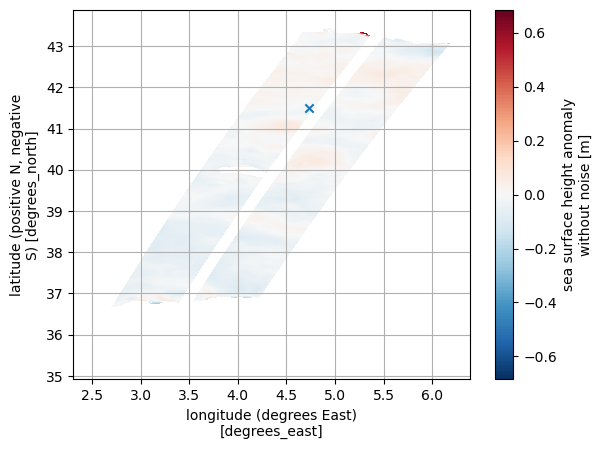

In [39]:
df_ = df.loc[24]
dss = xr.open_dataset(
    dfs.where(
        (dfs.pass_number == df_.pass_number) & (dfs.cycle_number == df_.cycle_number)
    )
    .dropna()
    .file.values[0]
)
dss.duacs_ssha_karin_2_filtered.plot(x="longitude", y="latitude")
print(haversine(dss.longitude, dss.latitude, df_.longitude, df_.latitude).min())
plt.scatter(df_.longitude, df_.latitude, marker="x")
plt.grid()

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


<xarray.DataArray ()>
array(0.07162707)


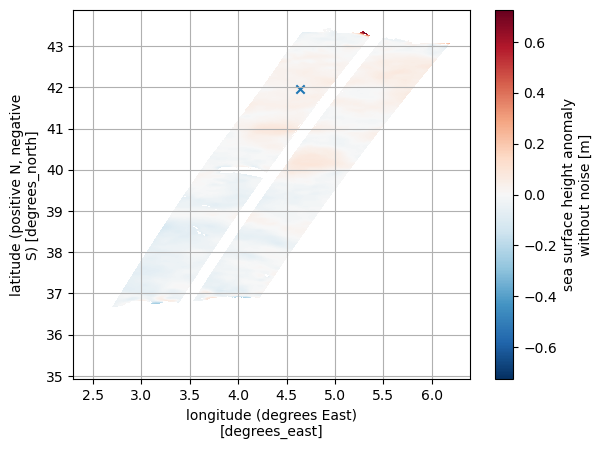

In [38]:
df_ = df.loc[19]
dss = xr.open_dataset(
    dfs.where(
        (dfs.pass_number == df_.pass_number) & (dfs.cycle_number == df_.cycle_number)
    )
    .dropna()
    .file.values[0]
)
dss.duacs_ssha_karin_2_filtered.plot(x="longitude", y="latitude")
print(haversine(dss.longitude, dss.latitude, df_.longitude, df_.latitude).min())
plt.scatter(df_.longitude, df_.latitude, marker="x")
plt.grid()

_______
# SWOT 2000

_______
# SWOT nadir

In [69]:
nadir_variables = [
    "cvl_nadir_flag_val_mle4_1hz",
    "cvl_nadir_ssha_mle4_1hz",
    "duacs_bias_karin_nadir",
    "duacs_nadir_orbit_error",
    "latitude_nadir",
    "longitude_nadir",
]

cycle = 500
swath = 3
dss = xr.open_dataset(
    "/Users/mdemol/DATA_KARIN/L3_2000/concatenated.zarr", decode_cf=False
)  # [nadir_variables + ['longitude', 'latitude', 'time']]
dss["time"] = dss.time * pd.Timedelta("1ns") + pd.to_datetime(
    "2023-04-01T23:43:46.791091968"
)
dss["num_lines"] = np.arange(len(dss.num_lines))
dss["num_pixels"] = np.arange(len(dss.num_pixels))
dss.set_coords(["num_lines", "num_pixels"])
dss0 = dss.sel(cycle_number=cycle)

In [36]:
df0__ = df0_.iloc[0]

In [46]:
dss

<xarray.Dataset> Size: 16MB
Dimensions:                      (cycle_number: 95, num_lines: 249,
                                  num_pixels: 69)
Coordinates:
  * cycle_number                 (cycle_number) float64 760B 478.0 ... 578.0
  * num_lines                    (num_lines) int64 2kB 0 1 2 3 ... 246 247 248
  * num_pixels                   (num_pixels) int64 552B 0 1 2 3 ... 65 66 67 68
Data variables:
    cvl_nadir_flag_val_mle4_1hz  (cycle_number, num_lines, num_pixels) uint8 2MB ...
    cvl_nadir_ssha_mle4_1hz      (cycle_number, num_lines, num_pixels) float64 13MB ...
    duacs_bias_karin_nadir       (cycle_number, num_lines) float64 189kB ...
    duacs_nadir_orbit_error      (cycle_number, num_lines) float64 189kB ...
    latitude_nadir               (cycle_number, num_lines) float64 189kB 39.2...
    longitude_nadir              (cycle_number, num_lines) float64 189kB 4.15...
    longitude                    (num_lines, num_pixels) float64 137kB ...
    latitude                     (num_lines, num_pixels) float64 137kB ...
    time                         (cycle_number, num_lines) datetime64[ns] 189kB ...
Attributes:
    latc:     41.590451
    lonc:     4.886678
    phi:      76.3215143328569

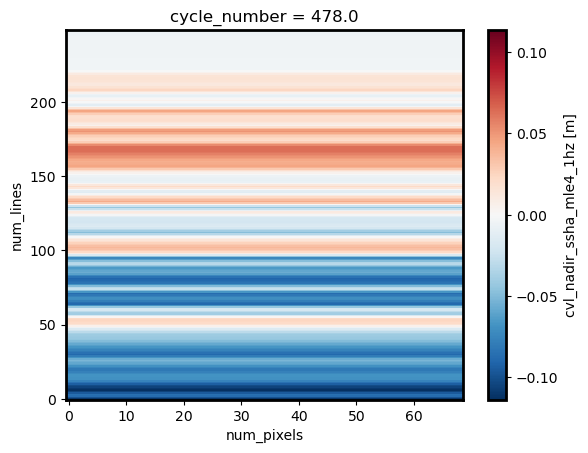

In [68]:
dss.cvl_nadir_ssha_mle4_1hz.isel(cycle_number=0).plot()

In [64]:
lond = df0__.longitude
latd = df0__.latitude


def compute_nadir_grad_one(swath, cycle, lond, latd, row_number, variables, dss):
    g = 9.81
    from scipy.interpolate import interp2d
    from scipy.interpolate import LinearNDInterpolator

    # Projection in local swath ref (y in the num_pixels direction and x in the num_lines
    xd, yd = lonlat2xy(
        dss.attrs["lonc"],
        dss.attrs["latc"],
        dss.attrs["phi"],
        lond,
        latd,
        lon1=None,
        lat1=None,
    )
    print(xd, yd)
    x, y = lonlat2xy(
        dss.attrs["lonc"],
        dss.attrs["latc"],
        dss.attrs["phi"],
        dss.longitude_nadir,
        dss.latitude_nadir,
        lon1=None,
        lat1=None,
    )
    dss["x"] = xr.DataArray(x, dims=["num_lines"])
    dss["y"] = xr.DataArray(y, dims=["num_lines"])
    dss = dss.set_coords(["x", "y"])

    dss["dist_to_drifter"] = np.sqrt((dss.x - xd) ** 2 + (dss.y - yd) ** 2)

    nadir_match = dss.where(dss.dist_to_drifter == dss.dist_to_drifter.min(), drop=True)

    ds_ = dss[variables]
    # Compute g * gradient
    dx = g * ds_.differentiate("x").rename({v: "ggradx_" + v for v in variables})

    dx = dx.where(dss.dist_to_drifter == dss.dist_to_drifter.min(), drop=True)

    print(row_number)

    return dx
    # return pd.Series(Dxd+Dyd, index=['ggradx_'+var for var in variables] + ['ggrady_'+var for var in variables] )


compute_nadir_grad_one(swath, cycle, lond, latd, 0, nadir_variables, dss0)

86560.47349699998 -42253.36165280321
0


<xarray.Dataset> Size: 2kB
Dimensions:                             (num_lines: 1, num_pixels: 69)
Coordinates:
    cycle_number                        float64 8B 500.0
  * num_lines                           (num_lines) int64 8B 177
  * num_pixels                          (num_pixels) int64 552B 0 1 2 ... 67 68
    x                                   (num_lines) float64 8B 8.599e+04
    y                                   (num_lines) float64 8B 693.0
Data variables:
    ggradx_cvl_nadir_flag_val_mle4_1hz  (num_lines, num_pixels) float64 552B ...
    ggradx_cvl_nadir_ssha_mle4_1hz      (num_lines, num_pixels) float64 552B ...
    ggradx_duacs_bias_karin_nadir       (num_lines) float64 8B 0.0
    ggradx_duacs_nadir_orbit_error      (num_lines) float64 8B 0.0
    ggradx_latitude_nadir               (num_lines) float64 8B 8.573e-05
    ggradx_longitude_nadir              (num_lines) float64 8B 2.862e-05
Attributes:
    latc:     41.590451
    lonc:     4.886678
    phi:      76.3215143328569

In [59]:
dss.dist_to_drifter.min()

AttributeError: 'Dataset' object has no attribute 'dist_to_drifter'

_________
_________
_________
# Test functions

In [9]:
lond, latd = (5, 41)
xd, yd = lonlat2xy(
    dss0.attrs["lonc"],
    dss0.attrs["latc"],
    dss0.attrs["phi"],
    lond,
    latd,
    lon1=None,
    lat1=None,
)

In [10]:
xd, yd

(124478.10060965866, -24845.89273099015)

In [7]:
x, y = lonlat2xy(
    dss0.attrs["lonc"],
    dss0.attrs["latc"],
    dss0.attrs["phi"],
    dss0.lon,
    dss0.lat,
    lon1=None,
    lat1=None,
)
dss0["x"] = xr.DataArray(x, dims=["num_lines", "num_pixels"])
dss0["y"] = xr.DataArray(y, dims=["num_lines", "num_pixels"])
dss0 = dss0.set_coords(["x", "y"])

In [48]:
ggrad_var = [
    "duacs_ssha_karin_2_calibrated",
    "duacs_ssha_karin_2_filtered",
    "cvl_mean_dynamic_topography_cnes_cls_22",
    "cvl_mean_sea_surface_cnes_22_hybrid",
    "cvl_ocean_tide_fes_2022",
    "cvl_ssha_reference",
    "cvl_swh_model",
]

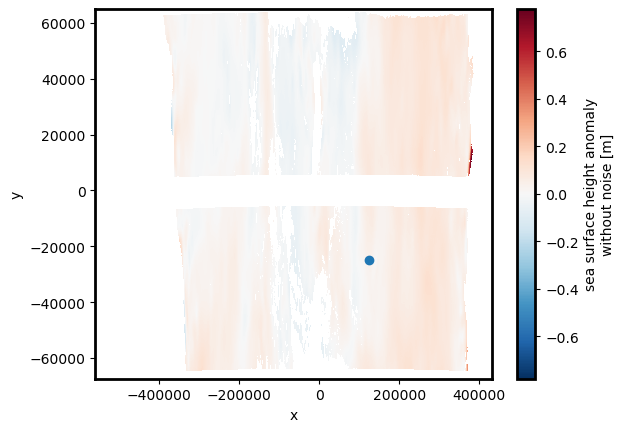

In [50]:
dss0.duacs_ssha_karin_2_filtered.plot(x="x", y="y")
plt.scatter(xd, yd)

In [129]:
dl = 2.5 * 1000
test_x = (dss0.x > xd - dl) & (dss0.x < xd + dl)
ds_ = dss0.where(test_x, drop=True)
test_y = (ds_.y > yd - dl) & (ds_.y < yd + dl)
ds_ = ds_.where(test_y, drop=True)
ds_

<xarray.Dataset> Size: 127kB
Dimensions:                                  (num_lines: 22, num_pixels: 20)
Coordinates:
    lat                                      (num_lines, num_pixels) float64 4kB ...
    lon                                      (num_lines, num_pixels) float64 4kB ...
    x                                        (num_lines, num_pixels) float64 4kB ...
    y                                        (num_lines, num_pixels) float64 4kB ...
Dimensions without coordinates: num_lines, num_pixels
Data variables: (12/36)
    ancillary_surface_classification_flag    (num_lines, num_pixels) float32 2kB ...
    cross_track_distance                     (num_lines, num_pixels) float32 2kB ...
    cvl_dac                                  (num_lines, num_pixels) float64 4kB ...
    cvl_distance_to_coast                    (num_lines, num_pixels) float64 4kB ...
    cvl_flag_val                             (num_lines, num_pixels) float32 2kB ...
    cvl_ice_conc                             (num_lines, num_pixels) float64 4kB ...
    ...                                       ...
    pass_number                              (num_lines, num_pixels) float32 2kB ...
    sig0_karin_2                             (num_lines, num_pixels) float32 2kB ...
    ssh_karin_2_qual                         (num_lines, num_pixels) float64 4kB ...
    time                                     (num_lines, num_pixels) datetime64[ns] 4kB ...
    time_tai                                 (num_lines, num_pixels) datetime64[ns] 4kB ...
    version                                  (num_lines, num_pixels) object 4kB ...
Attributes:
    latc:     39.961324
    lonc:     4.3749
    phi:      76.80931729750102

In [86]:
box_x = np.arange(ds_.x.min(), ds_.x.max(), 125)
box_y = np.arange(ds_.y.min(), ds_.y.max(), 125)

In [123]:
ds_ = ds_.where(ds_.duacs_ssha_karin_2_filtered != np.nan, drop=True)

In [173]:
from scipy.interpolate import interp2d

Z = ds_.duacs_ssha_karin_2_filtered.values.ravel()
X = ds_.x.values.ravel()
Y = ds_.y.values.ravel()
_ds = xr.Dataset(data_vars=dict(x=(["a"], X), y=(["a"], Y), z=(["a"], Z)))
_ds = _ds.dropna("a")


f = interp2d(_ds.x, _ds.y, _ds.z)
Znew = f(box_x, box_y)

In [176]:
len(box_x), len(box_y)

(41, 39)

In [177]:
np.shape(Znew)

(39, 41)

In [179]:
da = xr.DataArray(Znew, coords={"x": box_x, "y": box_y}, dims=["y", "x"])

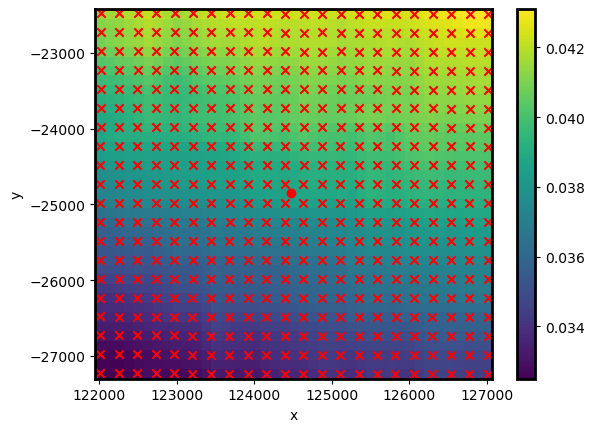

In [187]:
da.plot()
plt.scatter(X, Y, marker="x", c="r")
plt.scatter(xd, yd, c="r")

In [181]:
dax = da.differentiate("x")
day = da.differentiate("y")

In [184]:
dax.interp(x=xd, y=yd)

<xarray.DataArray ()> Size: 8B
array(8.71644815e-07)
Coordinates:
    x        float64 8B 1.245e+05
    y        float64 8B -2.485e+04